In [55]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split
import mlflow
import missingno as msno
import matplotlib.pyplot as plt

In [56]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [53]:
mlflow.set_experiment("Exp 4.3 - Model Selection")

2025/06/09 15:57:54 INFO mlflow.tracking.fluent: Experiment with name 'Exp 4.3 - Model Selection' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/189106432037458338', creation_time=1749464874038, experiment_id='189106432037458338', last_update_time=1749464874038, lifecycle_stage='active', name='Exp 4.3 - Model Selection', tags={}>

In [57]:
from sklearn import set_config
set_config(transform_output="pandas")

In [58]:
data = pd.read_csv('../data/processed/data_processed_v2.csv')

In [59]:
data.head()

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type,time_taken
0,37.0,4.9,sunny,high,2.0,snack,motorcycle,0.0,no,urban,1,15.0,morning,3.025149,short,24
1,34.0,4.5,stormy,jam,2.0,snack,scooter,1.0,no,metropolitian,0,5.0,evening,20.183530,very_long,33
2,23.0,4.4,sandstorms,low,0.0,drinks,motorcycle,1.0,no,urban,1,15.0,morning,1.552758,short,26
3,38.0,4.7,sunny,medium,0.0,buffet,motorcycle,1.0,no,metropolitian,0,10.0,evening,7.790401,medium,21
4,32.0,4.6,cloudy,high,1.0,snack,scooter,1.0,no,metropolitian,1,15.0,afternoon,6.210138,medium,30


In [60]:
data.isna().sum()

age                    1854
ratings                1908
weather                 525
traffic                 510
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     993
festival                228
city_type              1198
is_weekend                0
pickup_time_minutes    1640
order_time_of_day      2070
distance               3630
distance_type          3630
time_taken                0
dtype: int64

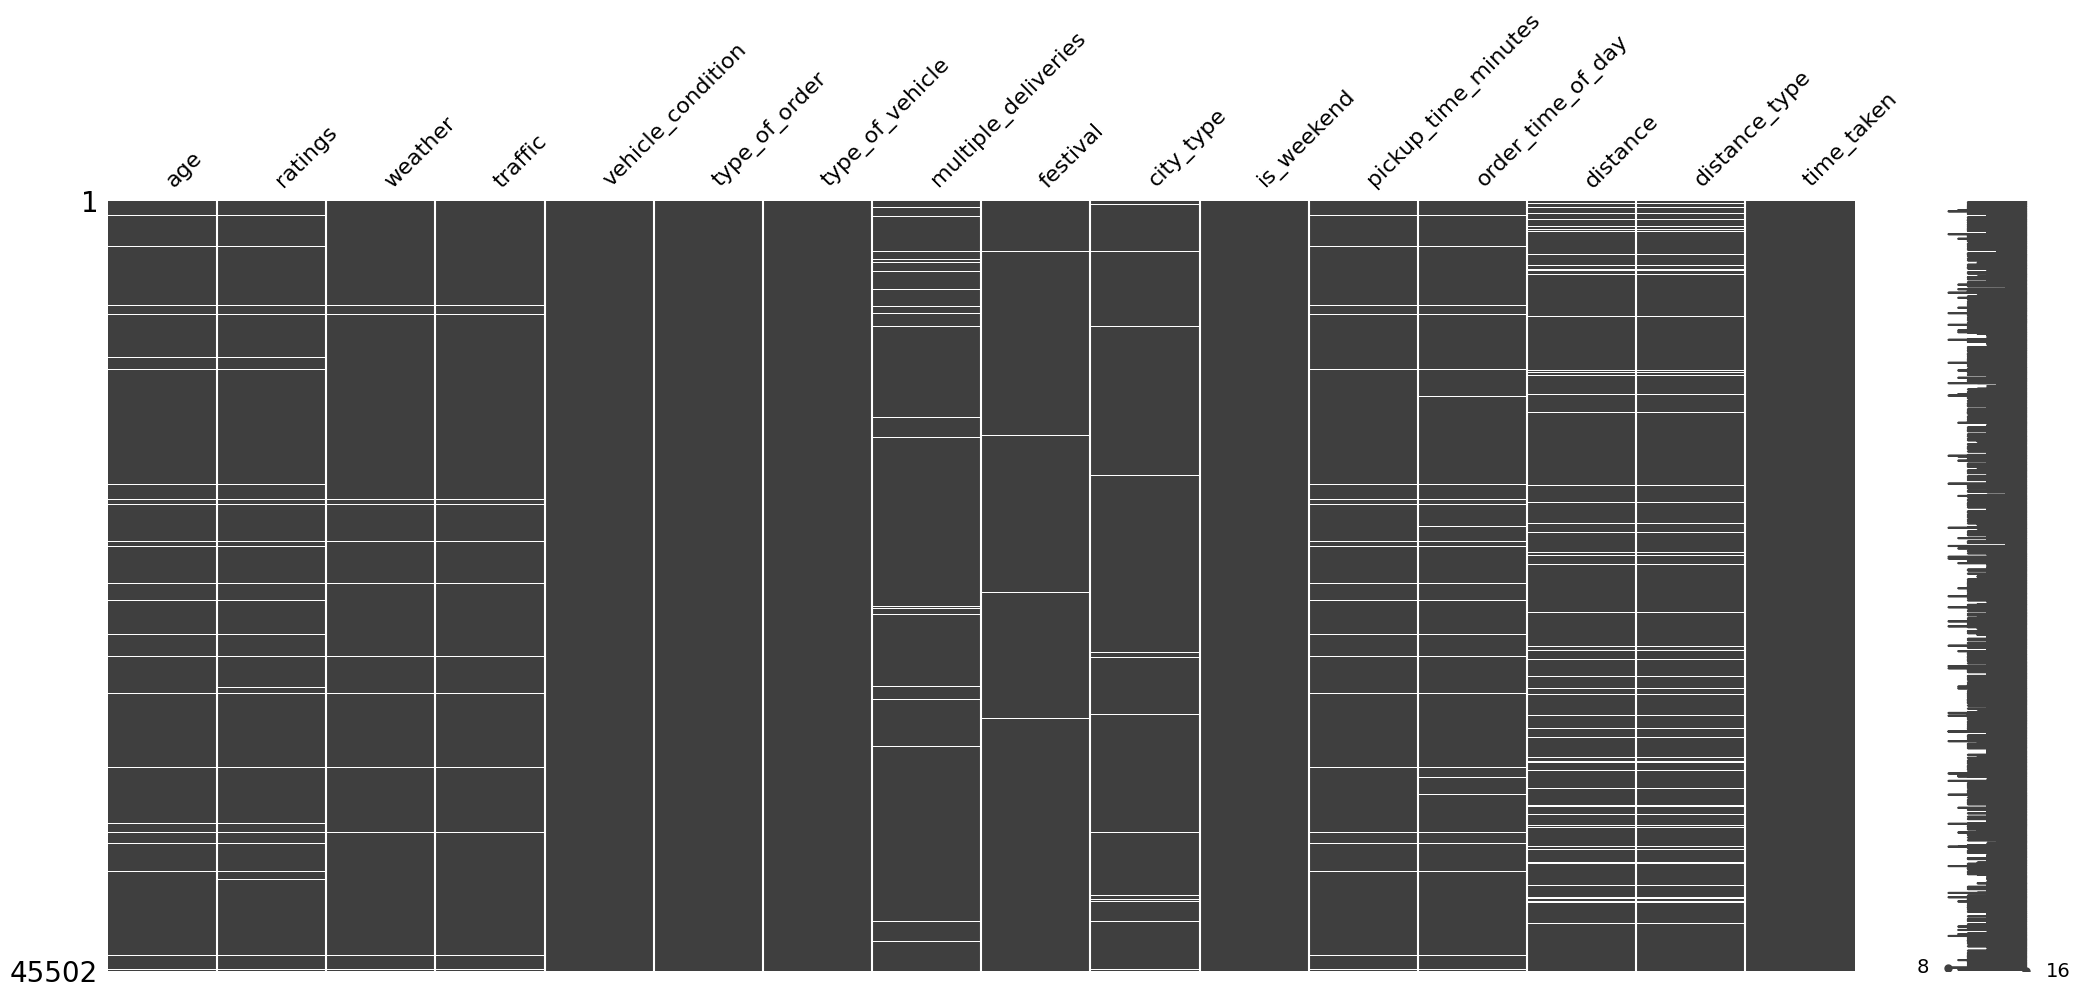

In [61]:
msno.matrix(data)
plt.show()

In [62]:
# missing colm list

missing_features = data.isna().any(axis=0).loc[lambda x: x].index
missing_features

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

### drop missing values

In [63]:
temp_data = data.copy().dropna()

In [64]:
X = temp_data.drop('time_taken', axis = 1)
y = temp_data['time_taken']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [66]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (30156, 15)
The shape of test data is (7539, 15)


In [67]:
# power transformer
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

### processing

In [68]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [69]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop = "first", handle_unknown = "ignore",
                                     sparse_output = False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories = [traffic_order,distance_type_order],
                                      encoded_missing_value = -999,
                                      handle_unknown = "use_encoded_value",
                                      unknown_value = -1), ordinal_cat_cols)
],remainder = "passthrough", n_jobs = -1, force_int_remainder_cols = False, verbose_feature_names_out = False)


preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [70]:
# build the pipeline
processing_pipeline = Pipeline(steps=[
                                ("preprocess",preprocessor)
                            ])

processing_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['age', 'ratings',
                                                   'pickup_time_minutes',
                                                   'distance']),
                                                 ('nominal_encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehicle',
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False))])

In [71]:
X_train_transform = processing_pipeline.fit_transform(X_train)
X_test_transform = processing_pipeline.fit_transform(X_test)

In [72]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna

In [73]:
def objective(trial):
    with mlflow.start_run(nested=True):
        model_name = trial.suggest_categorical("model", ["SVM", "RF", "KNN", "GB", "XGB", "LGBM"])

        model_params = {}

        if model_name == "SVM":
            kernel = trial.suggest_categorical("kernel_svm", ["linear", "poly", "rbf"])
            model_params["kernel"] = kernel

            if kernel == "linear":
                model_params["C"] = trial.suggest_float("c_linear", 0.01, 10, log=True)
            elif kernel == "poly":
                model_params["C"] = trial.suggest_float("c_poly", 0.01, 10, log=True)
                model_params["degree"] = trial.suggest_int("degree_poly", 1, 5)
            else:  # "rbf"
                model_params["C"] = trial.suggest_float("c_rbf", 0.01, 100, log=True)
                model_params["gamma"] = trial.suggest_float("gamma_rbf", 0.001, 10, log=True)
            model = SVR(**model_params)

        elif model_name == "RF":
            model_params = {
                "n_estimators": trial.suggest_int("n_estimators_rf", 10, 200),
                "max_depth": trial.suggest_int("max_depth_rf", 2, 20),
                "random_state": 42,
                "n_jobs": -1
            }
            model = RandomForestRegressor(**model_params)

        elif model_name == "GB":
            model_params = {
                "n_estimators": trial.suggest_int("n_estimators_gb", 10, 200),
                "learning_rate": trial.suggest_float("learning_rate_gb", 0.01, 1, log=True),
                "max_depth": trial.suggest_int("max_depth_gb", 2, 20),
                "random_state": 42
            }
            model = GradientBoostingRegressor(**model_params)

        elif model_name == "KNN":
            model_params = {
                "n_neighbors": trial.suggest_int("n_neighbors_knn", 1, 25),
                "weights": trial.suggest_categorical("weights_knn", ["uniform", "distance"]),
                "n_jobs": -1
            }
            model = KNeighborsRegressor(**model_params)

        elif model_name == "XGB":
            model_params = {
                "n_estimators": trial.suggest_int("n_estimators_xgb", 10, 200),
                "learning_rate": trial.suggest_float("learning_rate_xgb", 0.01, 0.5, log=True),
                "max_depth": trial.suggest_int("max_depth_xgb", 2, 20),
                "random_state": 42,
                "n_jobs": -1
            }
            model = XGBRegressor(**model_params)

        elif model_name == "LGBM":
            model_params = {
                "n_estimators": trial.suggest_int("n_estimators_lgbm", 10, 200),
                "learning_rate": trial.suggest_float("learning_rate_lgbm", 0.01, 0.5, log=True),
                "max_depth": trial.suggest_int("max_depth_lgbm", 2, 20),
                "random_state": 42
            }
            model = LGBMRegressor(**model_params)

        # Train
        model.fit(X_train_transform, y_train_pt.values.ravel())

        # Log parameters
        mlflow.log_params(model_params)
        mlflow.log_param("model", model_name)

        # Predict
        y_pred_test = model.predict(X_test_transform)
        y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1, 1))

        # Evaluate
        error = mean_absolute_error(y_test, y_pred_test_org)

        mlflow.log_metric("MAE", error)
        return error

In [74]:
import optuna
import mlflow

# optuna study
study = optuna.create_study(direction="minimize", study_name="model_selection")

with mlflow.start_run(run_name="Best Model") as parent:
    # Optimizing objective function
    study.optimize(objective, n_trials=30, n_jobs=-1)

    # Log the best parameters and score
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_score", study.best_value)

[I 2025-06-09 16:01:48,082] A new study created in memory with name: model_selection


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.077231 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 352
[LightGBM] [Info] Number of data points in the train set: 30156, number of used features: 25
[LightGBM] [Info] Start training from score -0.000000


[I 2025-06-09 16:01:48,753] Trial 3 finished with value: 3.176011800765991 and parameters: {'model': 'XGB', 'n_estimators_xgb': 39, 'learning_rate_xgb': 0.07725612538050133, 'max_depth_xgb': 7}. Best is trial 3 with value: 3.176011800765991.
[I 2025-06-09 16:01:48,808] Trial 5 finished with value: 3.067781935957969 and parameters: {'model': 'RF', 'n_estimators_rf': 22, 'max_depth_rf': 13}. Best is trial 5 with value: 3.067781935957969.


🏃 View run suave-stag-826 at: http://127.0.0.1:5000/#/experiments/189106432037458338/runs/c450a57f41df44169dab075b4730a07e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/189106432037458338
🏃 View run youthful-zebra-287 at: http://127.0.0.1:5000/#/experiments/189106432037458338/runs/af7cf923ede24b3e877cc95fe4fe1fac
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/189106432037458338


[I 2025-06-09 16:01:49,071] Trial 9 finished with value: 3.542518529369887 and parameters: {'model': 'RF', 'n_estimators_rf': 16, 'max_depth_rf': 8}. Best is trial 5 with value: 3.067781935957969.
[I 2025-06-09 16:01:49,180] Trial 6 finished with value: 3.2997655868530273 and parameters: {'model': 'XGB', 'n_estimators_xgb': 130, 'learning_rate_xgb': 0.07556472324885681, 'max_depth_xgb': 4}. Best is trial 5 with value: 3.067781935957969.


...

🏃 View run secretive-steed-346 at: http://127.0.0.1:5000/#/experiments/189106432037458338/runs/5cc070e43c484649bb80b94e91603cb8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/189106432037458338


[I 2025-06-09 16:05:26,196] Trial 24 finished with value: 3.7605103241029196 and parameters: {'model': 'SVM', 'kernel_svm': 'poly', 'c_poly': 0.6166648826875627, 'degree_poly': 5}. Best is trial 19 with value: 3.0191647486920634.


🏃 View run valuable-loon-987 at: http://127.0.0.1:5000/#/experiments/189106432037458338/runs/6ecda2a6591342c58c898ea88148fc08
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/189106432037458338


[I 2025-06-09 16:05:42,965] Trial 14 finished with value: 4.675433031293548 and parameters: {'model': 'SVM', 'kernel_svm': 'linear', 'c_linear': 9.424134270522035}. Best is trial 19 with value: 3.0191647486920634.


🏃 View run monumental-stoat-201 at: http://127.0.0.1:5000/#/experiments/189106432037458338/runs/94a651ff8ec04d0582ed6c51c96c1e61
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/189106432037458338
🏃 View run Best Model at: http://127.0.0.1:5000/#/experiments/189106432037458338/runs/13853c47824c4163bdbe338ed8919d2f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/189106432037458338
